# 5-Layer CNN for Writer Identification

## 1. Dataset Preprocessing

### 1.1 File Parsing and Importing the Data

In [1]:
import os

def parse_file_correct(file_path):
    strokes = {}
    
    with open(file_path, "r") as f:
        lines = f.readlines() 
    
    # skip headers (first 3 lines)
    data_lines = lines[3:]
    
    for line in data_lines:
        line = line.strip()
        if not line or line == "PEN_DOWN" or line == "PEN_UP":
            continue
        
        parts = line.split()
        if len(parts) < 4:
            continue
        
        x = float(parts[0])
        y = float(parts[1])
        stroke_id = int(parts[3])
        
        if stroke_id not in strokes:
            strokes[stroke_id] = []
        
        strokes[stroke_id].append((x, y))
    
    # sort strokes by stroke_id and return as list
    ordered_strokes = [strokes[k] for k in sorted(strokes.keys())]
    return ordered_strokes


def parse_character_name(file_path):
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("CHARACTER_NAME"):
                # handles "CHARACTER_NAME : AE"
                return line.split(":")[1].strip()
    return None  # if missing

In [2]:
character_labels = []
dataset = []
labels = []

base_path = "characters_dataset"
for writer_folder in sorted(os.listdir(base_path)):
    writer_path = os.path.join(base_path, writer_folder)
    if not os.path.isdir(writer_path):
        continue

    writer_id = int(writer_folder[1:])

    for file in sorted(os.listdir(writer_path)):  # sort for stable ordering
        if not file.endswith(".txt"):
            continue

        file_path = os.path.join(writer_path, file)

        # your existing stroke parser
        strokes = parse_file_correct(file_path)

        # new: character name
        char_name = parse_character_name(file_path)

        dataset.append(strokes)
        labels.append(writer_id)
        character_labels.append(char_name)

print("Loaded:", len(dataset))
print("Example:", labels[0], character_labels[0], "num_strokes =", len(dataset[0]))

Loaded: 8030
Example: 1 A num_strokes = 3


### 1.2 Image Reconstruction with PIL

In [3]:
from PIL import Image, ImageDraw

def strokes_to_image(strokes, size=128, padding=8, line_width=2):

    # collect all points
    pts = [(x, y) for stroke in strokes for (x, y) in stroke]

    if len(pts) < 2:
        return Image.new("L", (size, size), color=255)

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    width = max(max_x - min_x, 1e-6)
    height = max(max_y - min_y, 1e-6)

    usable = size - 2 * padding
    scale = usable / max(width, height)

    def transform(x, y):
        x = (x - min_x) * scale + padding
        y = (y - min_y) * scale + padding
        return (x, y)

    img = Image.new("L", (size, size), color=255)
    draw = ImageDraw.Draw(img)

    for stroke in strokes:
        if len(stroke) < 2:
            continue
        pts = [transform(x, y) for x, y in stroke]
        draw.line(pts, fill=0, width=line_width)

    return img

In [4]:
import os, re
import pandas as pd

ROOT = "characters_dataset"
OUT_DIR = "cnn_data/images_128"
META_PATH = "cnn_data/metadata.csv"

os.makedirs(OUT_DIR, exist_ok=True)

records = []
count_saved = 0

writers = sorted([d for d in os.listdir(ROOT) if d.startswith("W")])
print("Found writers:", len(writers))

for w in writers:
    w_path = os.path.join(ROOT, w)
    txt_files = sorted([f for f in os.listdir(w_path) if f.endswith(".txt")])

    out_w_dir = os.path.join(OUT_DIR, w)
    os.makedirs(out_w_dir, exist_ok=True)

    for fname in txt_files:
        src_path = os.path.join(w_path, fname)

        strokes = parse_file_correct(src_path)
        char = parse_character_name(src_path)  # separate function that reads header
        img = strokes_to_image(strokes, size=128)

        char_safe = re.sub(r"[^A-Za-z0-9]+", "_", str(char))
        out_name = f"{w}__{char_safe}__{fname.replace('.txt','')}.png"
        out_path = os.path.join(out_w_dir, out_name)

        img.save(out_path)
        count_saved += 1

        records.append({
            "writer_id": w,
            "character": char,
            "source_txt": src_path,
            "image_path": out_path
        })

    print(f"{w}: saved {len(txt_files)} images")

df = pd.DataFrame(records)
df.to_csv(META_PATH, index=False)

print("TOTAL saved:", count_saved)
print("Metadata:", META_PATH)

Found writers: 45
W1: saved 183 images
W10: saved 183 images
W11: saved 183 images
W12: saved 183 images
W13: saved 183 images
W14: saved 183 images
W15: saved 183 images
W16: saved 183 images
W17: saved 183 images
W18: saved 183 images
W19: saved 183 images
W2: saved 183 images
W20: saved 183 images
W21: saved 183 images
W22: saved 183 images
W23: saved 183 images
W24: saved 183 images
W25: saved 183 images
W26: saved 183 images
W27: saved 183 images
W28: saved 183 images
W29: saved 183 images
W3: saved 183 images
W30: saved 183 images
W31: saved 183 images
W32: saved 183 images
W33: saved 183 images
W34: saved 183 images
W35: saved 183 images
W36: saved 183 images
W37: saved 183 images
W38: saved 183 images
W39: saved 183 images
W4: saved 183 images
W40: saved 183 images
W41: saved 183 images
W42: saved 183 images
W43: saved 183 images
W44: saved 183 images
W45: saved 183 images
W5: saved 30 images
W6: saved 131 images
W7: saved 183 images
W8: saved 183 images
W9: saved 183 images
TO

### 1.3 Train / Validation / Test Split

In [5]:
import os
import torch
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np

DATA_DIR = "cnn_data/images_128"
BATCH_SIZE = 128 
SEED = 42

train_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((128,128)),
    transforms.RandomAffine(degrees=5, translate=(0.03,0.03), scale=(0.95,1.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset without transforms first
full_ds = datasets.ImageFolder(DATA_DIR)

# labels for each image
labels = [label for _, label in full_ds.samples]
indices = np.arange(len(labels))

# --- first split: train (70%) and temp (30%) ---
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

# labels for temp set
temp_labels = [labels[i] for i in temp_idx]

# --- second split: validation (15%) and test (15%) ---
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

train_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=train_tf), train_idx)
val_ds   = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tf), val_idx)
test_ds  = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tf), test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(
    "Train:", len(train_ds),
    "Val:", len(val_ds),
    "Test:", len(test_ds)
)

Train: 5624 Val: 1205 Test: 1206


## 2. 5-Layer CNN Architecture (Batch Normalization, ReLU, Max Pooling, Linear Classifier)

In [6]:
import torch.nn as nn

class WriterCNN(nn.Module):
    def __init__(self, num_classes=45):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), 
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),# remove this for 17.6%%
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Create the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = WriterCNN(num_classes=45).to(device)

# Quick sanity check: pass a dummy batch through
dummy = torch.randn(4, 1, 128, 128).to(device)
out = model(dummy)
print("Output shape:", out.shape)  # should be: torch.Size([4, 45])

Output shape: torch.Size([4, 45])


## 3. Model Training and Evaluation

### 3.1 Training Configuration (Defining Helper Functions)

In [7]:
# STEP 3: Train the CNN (PyTorch)

import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()                 # softmax cross-entropy for multi-class
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3 , weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

# --- train / eval loops ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)                    # (B,45)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_seen += bs

    avg_loss = total_loss / total_seen
    avg_acc = total_correct / total_seen
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_seen += bs

    avg_loss = total_loss / total_seen
    avg_acc = total_correct / total_seen
    return avg_loss, avg_acc

### 3.2 Training Loop

In [8]:
# --- run training ---
best_val_acc = 0.0
EPOCHS = 25

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Step scheduler (ReduceLROnPlateau expects a metric)
    scheduler.step(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    # Save best model (based on val accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model!")

# Evaluate ONCE on test at the end
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"FINAL TEST | loss {test_loss:.4f} acc {test_acc:.4f}")

Epoch 01/25 | train loss 3.7994 acc 0.0357 | val loss 3.7792 acc 0.0340
Saved new best model!
Epoch 02/25 | train loss 3.5374 acc 0.0871 | val loss 3.5368 acc 0.0722
Saved new best model!
Epoch 03/25 | train loss 3.3563 acc 0.1166 | val loss 3.4561 acc 0.0739
Saved new best model!
Epoch 04/25 | train loss 3.2096 acc 0.1419 | val loss 3.1625 acc 0.1311
Saved new best model!
Epoch 05/25 | train loss 3.0886 acc 0.1721 | val loss 3.3267 acc 0.1120
Epoch 06/25 | train loss 2.9677 acc 0.1924 | val loss 3.7860 acc 0.0647
Epoch 07/25 | train loss 2.8822 acc 0.2141 | val loss 3.1822 acc 0.1693
Saved new best model!
Epoch 08/25 | train loss 2.8024 acc 0.2235 | val loss 3.2057 acc 0.1344
Epoch 09/25 | train loss 2.7652 acc 0.2360 | val loss 3.0043 acc 0.1809
Saved new best model!
Epoch 10/25 | train loss 2.7333 acc 0.2457 | val loss 2.7460 acc 0.2357
Saved new best model!
Epoch 11/25 | train loss 2.6870 acc 0.2559 | val loss 3.1542 acc 0.1693
Epoch 12/25 | train loss 2.6261 acc 0.2712 | val loss 

### 3.3 Validation Evaluation

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

### 3.4 Final Confusion Matrix

In [10]:
cm = confusion_matrix(all_labels, all_preds)
class_labels = [f"W{i}" for i in range(1, 46)]

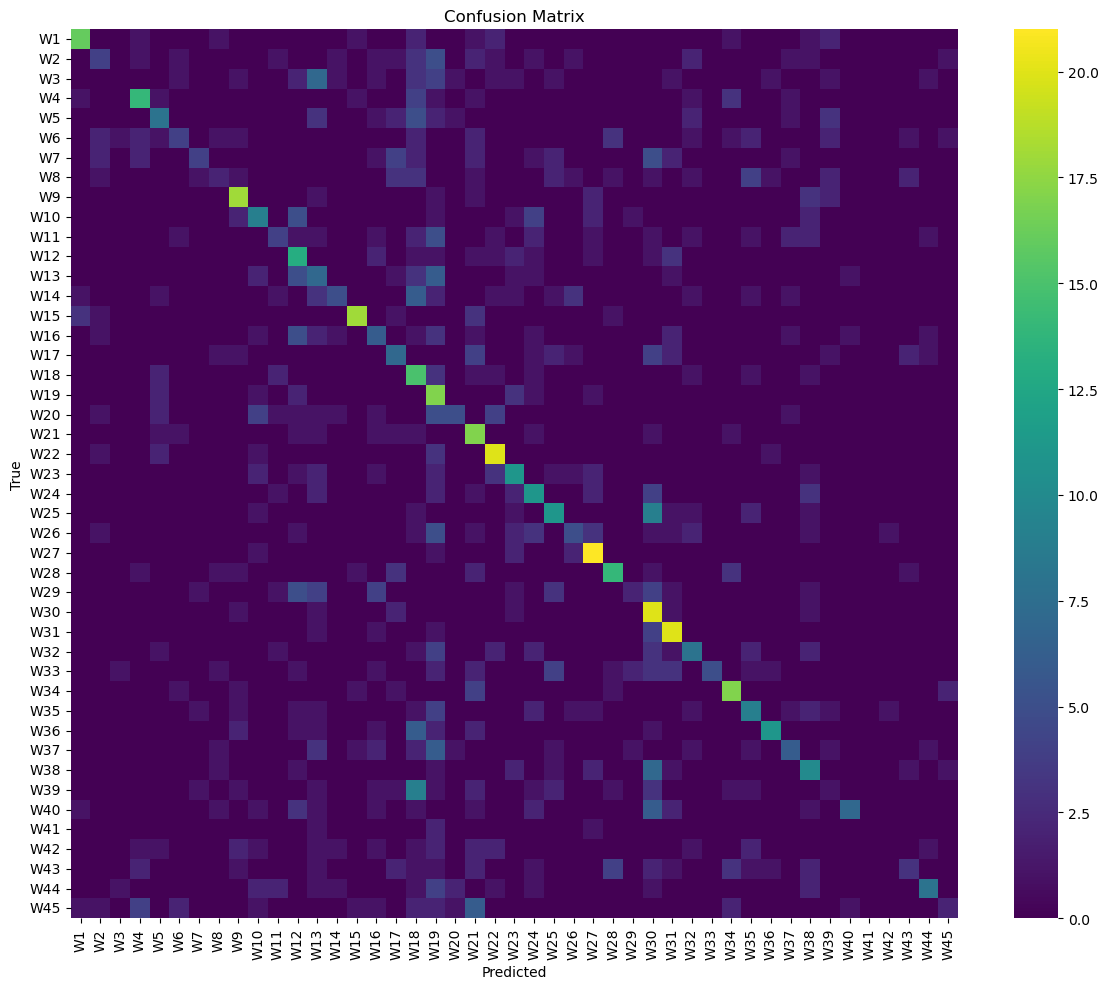

In [11]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="viridis",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()